In [1]:
import numpy as np
from matplotlib.pyplot import *
# from cmblunsplus
from cmblensplus import curvedsky
from cmblensplus.utils import constant as c, quad_func, cmb, cosmology

Importing /global/u1/t/toshiyan/.conda/envs/py_v3_13/lib/python3.13/site-packages/cmblensplus/utils/__init__.py


In [2]:
rlmin, rlmax = 2, 4000
l = np.linspace(0,rlmax,rlmax+1)

In [3]:
# TT,TE,EE+lowE+lensing PR3 (Table 2)
ucl, lcl, ckk = cosmology.calc_cmb_aps(rlmax,cltype=['unlens','lens','clkk'],
        H0=67.36,ombh2=0.02237,omch2=0.1200,As=2.1e-9,ns=0.9646)
ucl[2] = ucl[3]
ucl[3] = ckk[:,0]*(4.)/(l*(l+1))**2

/tmp/ipykernel_566501/2877312155.py:5: RuntimeWarning: invalid value encountered in divide
  ucl[3] = ckk[:,0]*(4.)/(l*(l+1))**2


In [4]:
# approximately 90 & 150 combined baseline (https://arxiv.org/abs/2503.00636)
sigP = 1. 
theta = 1.
nl  = np.zeros((4,rlmax+1))
nl[0,:] = .5*(sigP*c.ac2rad/c.Tcmb)**2*np.exp(l*(l+1)*(theta*c.ac2rad)**2/(8.*np.log(2.)))
nl[0,3000:] = 1e30
nl[1,:] = 2*nl[0,:]
nl[2,:] = 2*nl[0,:]
ocl = lcl + nl

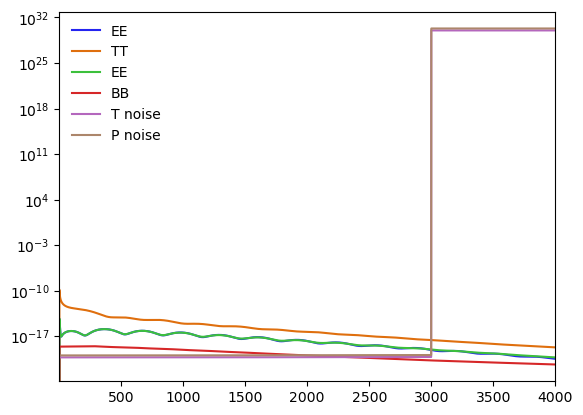

In [5]:
xlim(rlmin,rlmax)
semilogy(ucl[1],label='EE')
semilogy(lcl[0],label='TT')
semilogy(lcl[1],label='EE')
semilogy(lcl[2],label='BB')
semilogy(l,nl[0,:],label='T noise')
semilogy(l,nl[1,:],label='P noise')
legend()

In [6]:
Lmax = 4000
L = np.linspace(0,Lmax,Lmax+1)
Lkap = L**2*(L+1)**2/4.

In [7]:
nlkk, nlcc = curvedsky.norm_quad.qall_iter(Lmax,rlmin,rlmax,ucl,lcl,ocl,eb='qe')
nlkk *= Lkap[None,:]
nlcc *= Lkap[None,:]

 norm qTTTE
 norm qTTEE
 norm qTEEE
 norm qMV
 norm qMV


In [8]:
Nlkk, Nlcc = curvedsky.norm_quad.qall_iter(Lmax,rlmin,rlmax,ucl,lcl,ocl,eb='iter')

 norm qTTTE
 norm qTTEE
 norm qTEEE
 norm qMV
 norm qMV


In [9]:
Nlkk *= Lkap[None,:]
Nlcc *= Lkap[None,:]

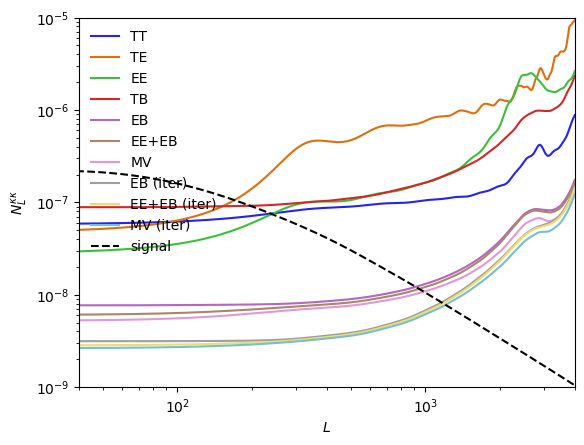

In [10]:
xlim(40,Lmax)
ylim(1e-9,1e-5)
xlabel(r'$L$')
ylabel(r'$N_L^{\kappa\kappa}$')
quad = ['TT','TE','EE','TB','EB','EE+EB','MV']
for i, q in enumerate(quad):
    loglog(L,nlkk[i],label=q)
loglog(L,Nlkk[4],label='EB (iter)')
loglog(L,Nlkk[5],label='EE+EB (iter)')
loglog(L,Nlkk[6],label='MV (iter)')
plot(L,ckk[:Lmax+1,0],color='k',label='signal',ls='--')
legend()

In [11]:
#np.savetxt('../data/nlkk_S4-like.dat',np.array((L,Nlkk[6,:])).T, header="L, MV(iter)")